# Install Required Libraries

In [1]:
pip install pandas matplotlib seaborn numpy

Note: you may need to restart the kernel to use updated packages.


# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset

In [3]:
df=pd.read_csv("C:/Users/asind/Downloads/RetailSalesEDA/retail_sales_dataset.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


# Check Datset Shape

df.shape

# Display Column Names

In [4]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

# Data Types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


# Check Missing Values

In [6]:
df.isnull()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False


In [7]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

# Convert Date Column

In [8]:
df["Date"]=pd.to_datetime(df["Date"])

# Descriptive Statistics

In [9]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


# Mean

df.mean(numeric_only=True)

# Median

In [10]:
df.median(numeric_only=True)

Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

# Mode

In [11]:
df.mode(numeric_only=True)

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
0,1,43.0,4.0,50.0,50.0
1,2,64.0,NaN,NaN,NaN
2,3,NaN,NaN,NaN,NaN
3,4,NaN,NaN,NaN,NaN
4,5,NaN,NaN,NaN,NaN
...,...,...,...,...,...
995,996,NaN,NaN,NaN,NaN
996,997,NaN,NaN,NaN,NaN
997,998,NaN,NaN,NaN,NaN
998,999,NaN,NaN,NaN,NaN


# Standard Deviation

In [12]:
df.std(numeric_only=True)

Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

# Time Series Analysis
# Monthly Sale

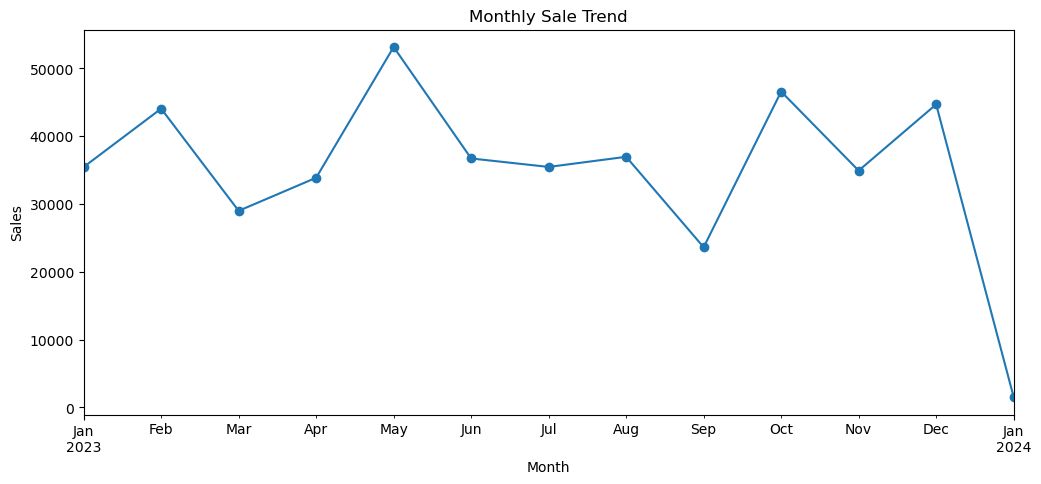

In [13]:
df["Month"]=df["Date"].dt.to_period("M")
monthly_sales=df.groupby("Month")["Total Amount"].sum()
plt.figure(figsize=(12,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sale Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# Quarterly Sale

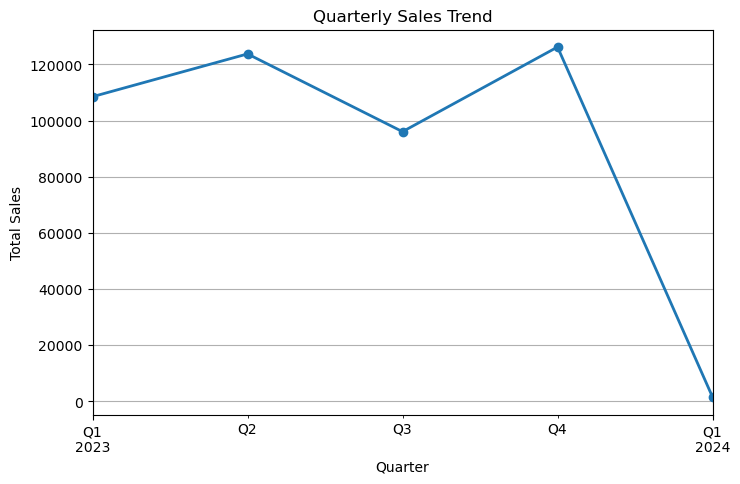

In [14]:
df["Quarter"] = df["Date"].dt.to_period("Q")
quarter_sales = df.groupby("Quarter")["Total Amount"].sum()
plt.figure(figsize=(8,5))
quarter_sales.plot(marker='o', linewidth=2)
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

# Customer Demographics
# Age Distribution

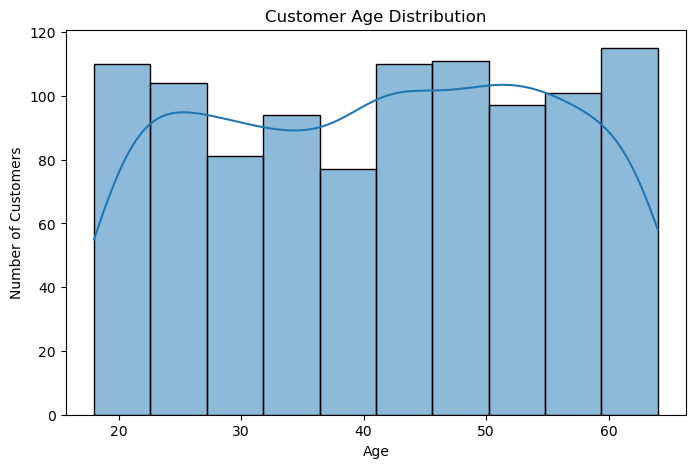

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=10, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

# Gender Distribution

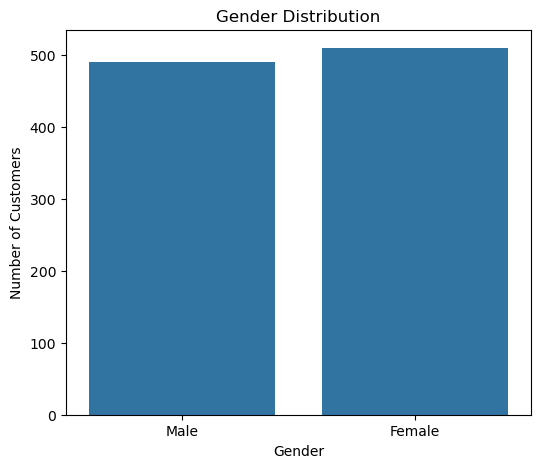

In [16]:
plt.figure(figsize=(6,5))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

# Product Analysis
# Top Product Categories by Revenue

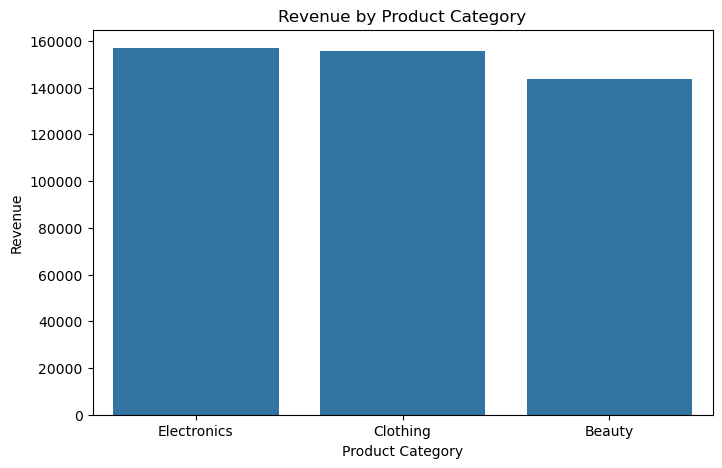

In [17]:
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.show()

# Top 10 Products

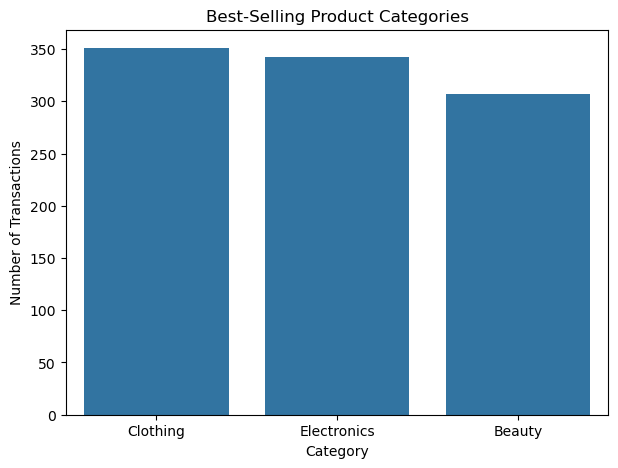

In [18]:
top_categories = df["Product Category"].value_counts()
plt.figure(figsize=(7,5))
sns.barplot(
    x=top_categories.index,
    y=top_categories.values
)
plt.title("Best-Selling Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Transactions")
plt.show()

# Heatmap
# Correlation Matrix

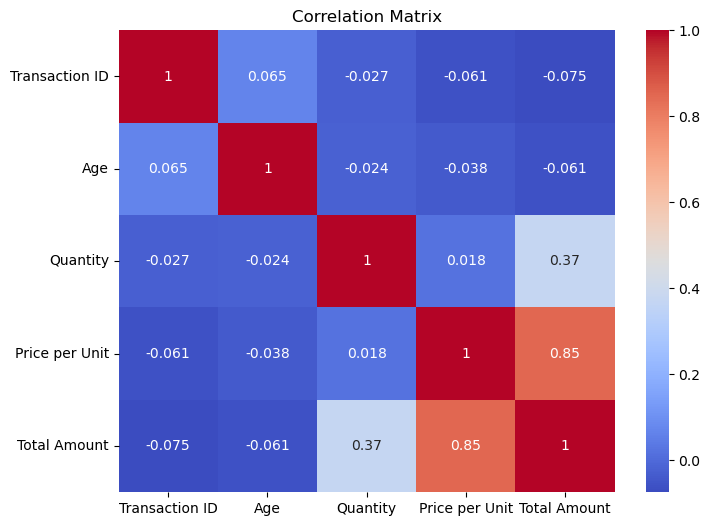

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

# Sales by Gender

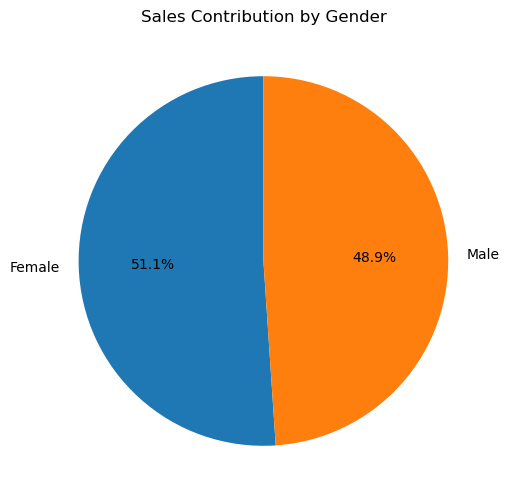

In [20]:
gender_sales = df.groupby("Gender")["Total Amount"].sum()
plt.figure(figsize=(6,6))
plt.pie(
    gender_sales,
    labels=gender_sales.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Sales Contribution by Gender")
plt.show()

# Conclusion

The exploratory data analysis provided valuable insights into customer behavior and sales performance.

## Business Recommendations

1. Increase inventory and promotional activities during high-sales months to maximize revenue.

2. Focus marketing efforts on the highest-performing product categories to improve profitability.

3. Design targeted campaigns for the dominant customer age groups to increase customer engagement.

4. Monitor low-performing months and introduce discounts or special offers to improve sales.

5. Use customer demographic information to personalize marketing strategies and enhance customer satisfaction.